In [16]:
import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'], check=True)

import os, shutil, yaml, cv2, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

print('Ultralytics YOLO san sang!')

Ultralytics YOLO san sang!


In [17]:
from pathlib import Path

BASE       = Path('/kaggle/input/datasets/ankizsem/doanai-aug/DoanAi_aug')
DATA_IMGS  = BASE / 'images'
DATA_LBLS  = BASE / 'labels'
SPLIT_DIR  = BASE / 'split_dataset'
WORK_DIR   = Path('/kaggle/working/dataset')

with open(BASE / 'classes_en.txt') as f:
    classes = [line.strip() for line in f if line.strip()]
with open(SPLIT_DIR / 'train_files.txt') as f:
    train_list = [l.strip() for l in f if l.strip()]
with open(SPLIT_DIR / 'valid_files.txt') as f:
    valid_list = [l.strip() for l in f if l.strip()]
with open(SPLIT_DIR / 'test_files.txt') as f:
    test_list = [l.strip() for l in f if l.strip()]

print(f'So class : {len(classes)}')
print(f'Train    : {len(train_list)} anh')
print(f'Val      : {len(valid_list)} anh')
print(f'Test     : {len(test_list)} anh')
print(f'Tong     : {len(train_list)+len(valid_list)+len(test_list)} anh')

So class : 67
Train    : 9845 anh
Val      : 1230 anh
Test     : 1230 anh
Tong     : 12305 anh


In [18]:
import shutil
from tqdm import tqdm

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

for split in ['train', 'val', 'test']:
    (WORK_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (WORK_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

def copy_files(file_list, split_name):
    count = 0
    for name in tqdm(file_list, desc=f'Copying {split_name}'):
        stem = Path(name).stem  # bỏ đuôi nếu có
        # Thử thêm đuôi .jpg và .png
        found_imgs = (
            list(DATA_IMGS.rglob(stem + '.jpg')) +
            list(DATA_IMGS.rglob(stem + '.png')) +
            list(DATA_IMGS.rglob(name + '.jpg')) +  # tên gốc + .jpg
            list(DATA_IMGS.rglob(name + '.png'))    # tên gốc + .png
        )
        if not found_imgs:
            continue
        img_src = found_imgs[0]
        shutil.copy(img_src, WORK_DIR / split_name / 'images' / img_src.name)
        found_lbls = (
            list(DATA_LBLS.rglob(stem + '.txt')) +
            list(DATA_LBLS.rglob(name + '.txt'))
        )
        if found_lbls:
            shutil.copy(found_lbls[0], WORK_DIR / split_name / 'labels' / found_lbls[0].name)
        count += 1
    return count

n_train = copy_files(train_list, 'train')
n_val   = copy_files(valid_list, 'val')
n_test  = copy_files(test_list,  'test')

total = n_train + n_val + n_test
print(f'Train : {n_train} anh ({n_train/total*100:.1f}%)')
print(f'Val   : {n_val}  anh ({n_val/total*100:.1f}%)')
print(f'Test  : {n_test} anh ({n_test/total*100:.1f}%)')
print(f'Tong  : {total} anh')

Copying test: 100%|██████████| 1230/1230 [21:35<00:00,  1.05s/it]

Train : 9845 anh (80.0%)
Val   : 1230  anh (10.0%)
Test  : 1230 anh (10.0%)
Tong  : 12305 anh


In [19]:
# Xem mau ten file trong txt vs ten file thuc te
with open(SPLIT_DIR / 'train_files.txt') as f:
    train_list_raw = [l.strip() for l in f if l.strip()]

# Mau txt
print('Mau train_files.txt:')
for l in train_list_raw[:5]:
    print(f'  "{l}"')

# Mau anh thuc te
print('\nMau anh thuc te trong images/:')
for p in list(DATA_IMGS.rglob('*'))[:5]:
    print(f'  "{p.name}"')

Mau train_files.txt:
  "000000_jpg.rf.b11f308f16626f9f795a148029c46d10"
  "000005_jpg.rf.d730849ae93a7c211a7c8f57ed851028"
  "000007_jpg.rf.226fe0751cf8ba445b8f87970e70f606"
  "000008_jpg.rf.bd6ae6db0f8c0eb727706bc322ce21ae"
  "00000_00000_00000_png.rf.55d47572c5980af0892b0c2ada6dae77"

Mau anh thuc te trong images/:
  "0779_augc24_03121.jpg"
  "0174_augc9_00621.jpg"
  "2910_augc28_04067.jpg"
  "0664.jpg"
  "3105_augc48_06691.jpg"


In [20]:
import yaml

data_yaml = {
    'path': str(WORK_DIR),
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc':    len(classes),
    'names': classes
}

yaml_path = Path('/kaggle/working/data.yaml')
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print('data.yaml da tao xong!')
print(f'  - Train : {n_train} anh (80.0%)')
print(f'  - Val   : {n_val}  anh (10.0%)')
print(f'  - Test  : {n_test} anh (10.0%)')
print(f'  - Classes: {len(classes)}')

data.yaml da tao xong!
  - Train : 9845 anh (80.0%)
  - Val   : 1230  anh (10.0%)
  - Test  : 1230 anh (10.0%)
  - Classes: 67


In [30]:
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else 'cpu'
print(f'Su dung: {"GPU" if device == 0 else "CPU"}')

model = YOLO('yolov8m.pt')

results = model.train(
    data     = str(yaml_path),
    epochs   = 50,
    imgsz    = 640,
    batch    = 16 if device == 0 else 4,
    device   = device,
    project  = '/kaggle/working',
    name     = 'doanai_yolov8m',
    patience = 10,
    save     = True,
    plots    = True,
    fliplr   = 0.0,
)

print('Training hoan thanh!')

Su dung: GPU
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=doanai_yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

In [31]:
from ultralytics import YOLO

model_best = YOLO('/kaggle/working/doanai_yolov8m/weights/best.pt')

metrics = model_best.val(
    data    = str(yaml_path),
    split   = 'test',
    verbose = False
)

print('\n' + '='*50)
print('   KET QUA TREN TAP TEST (chua tung thay)')
print('='*50)
print(f'  mAP@50   : {metrics.box.map50*100:.1f}%')
print(f'  mAP@50-95: {metrics.box.map*100:.1f}%')
print(f'  Precision: {metrics.box.mp*100:.1f}%')
print(f'  Recall   : {metrics.box.mr*100:.1f}%')
print('='*50)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,878,553 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2081.6±1241.1 MB/s, size: 157.4 KB)
val: Scanning /kaggle/working/dataset/test/labels.cache... 1230 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1230/1230 368.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 77/77 3.1it/s 25.2s0.5ss
                   all       1230       3936      0.977      0.968      0.982      0.819
Speed: 0.7ms preprocess, 16.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-4

   KET QUA TREN TAP TEST (chua tung thay)
  mAP@50   : 98.2%
  mAP@50-95: 81.9%
  Precision: 97.7%
  Recall   : 96.8%


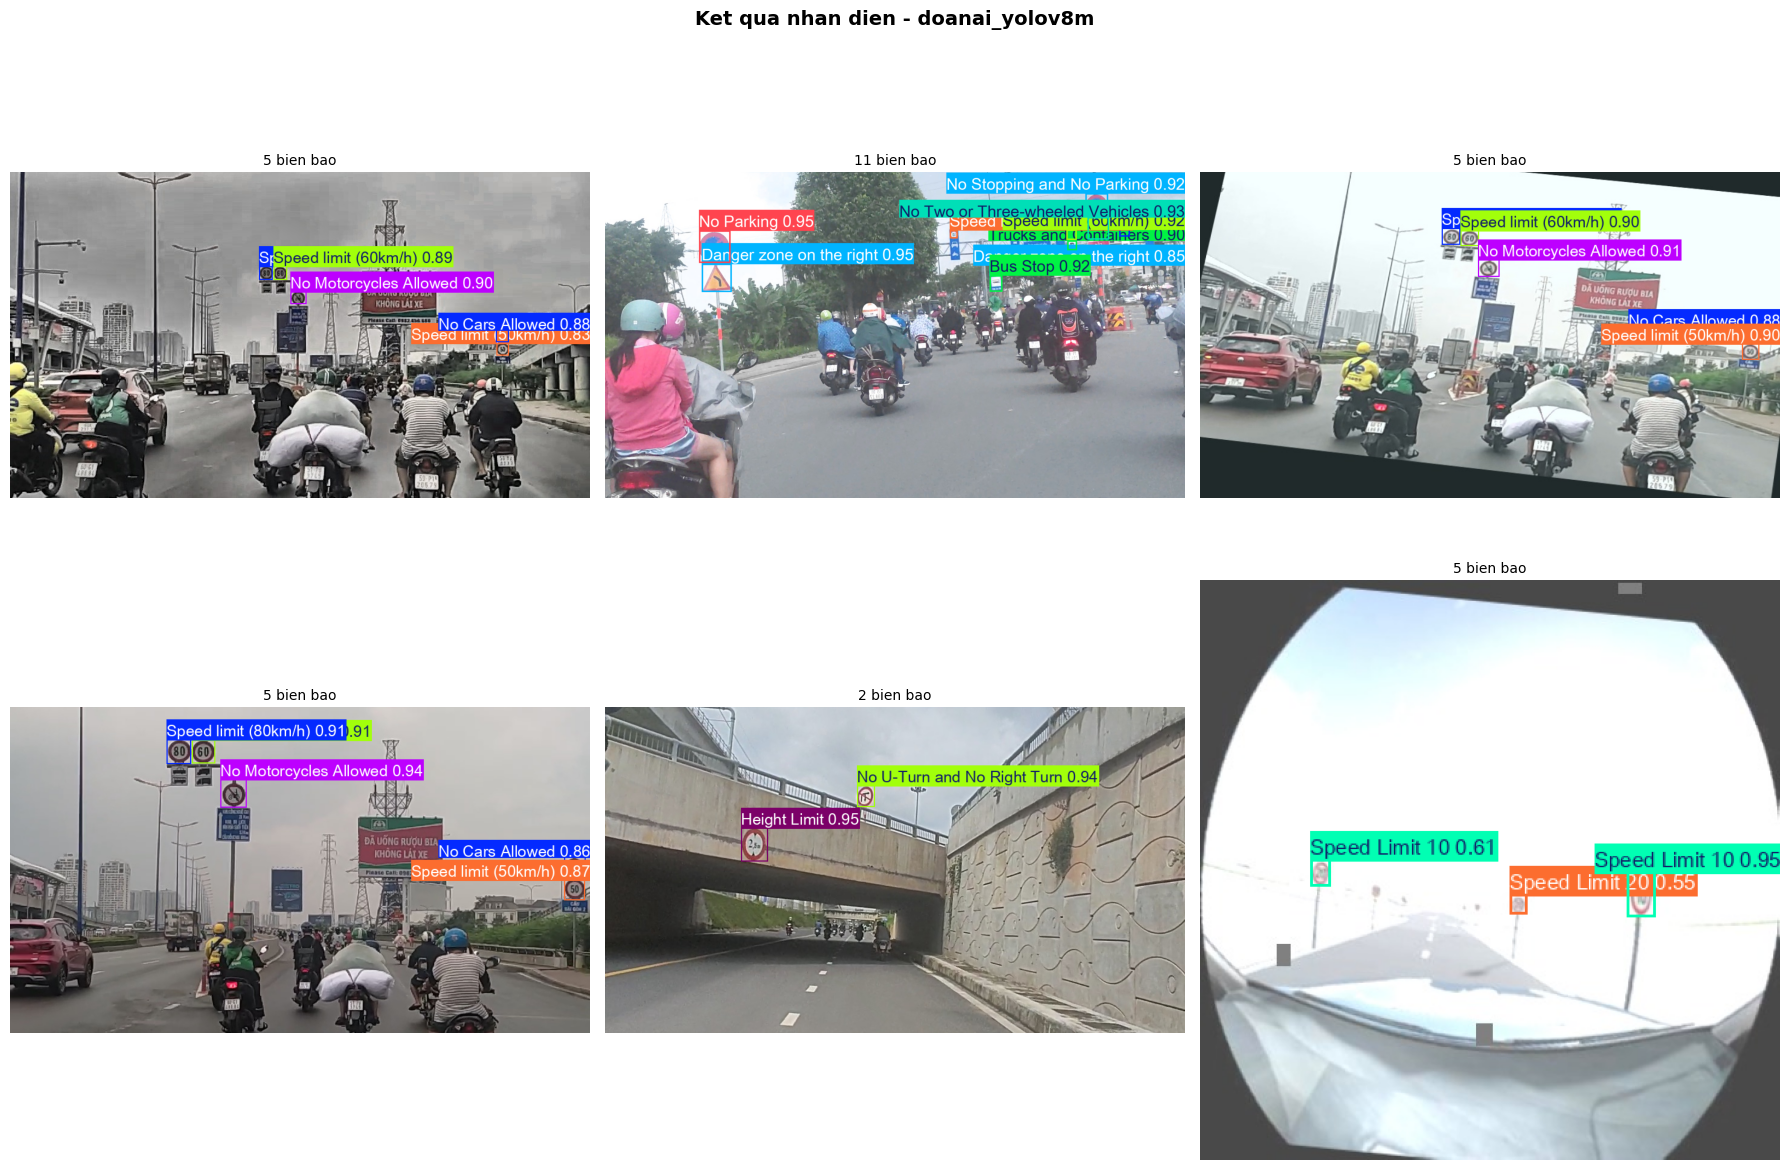

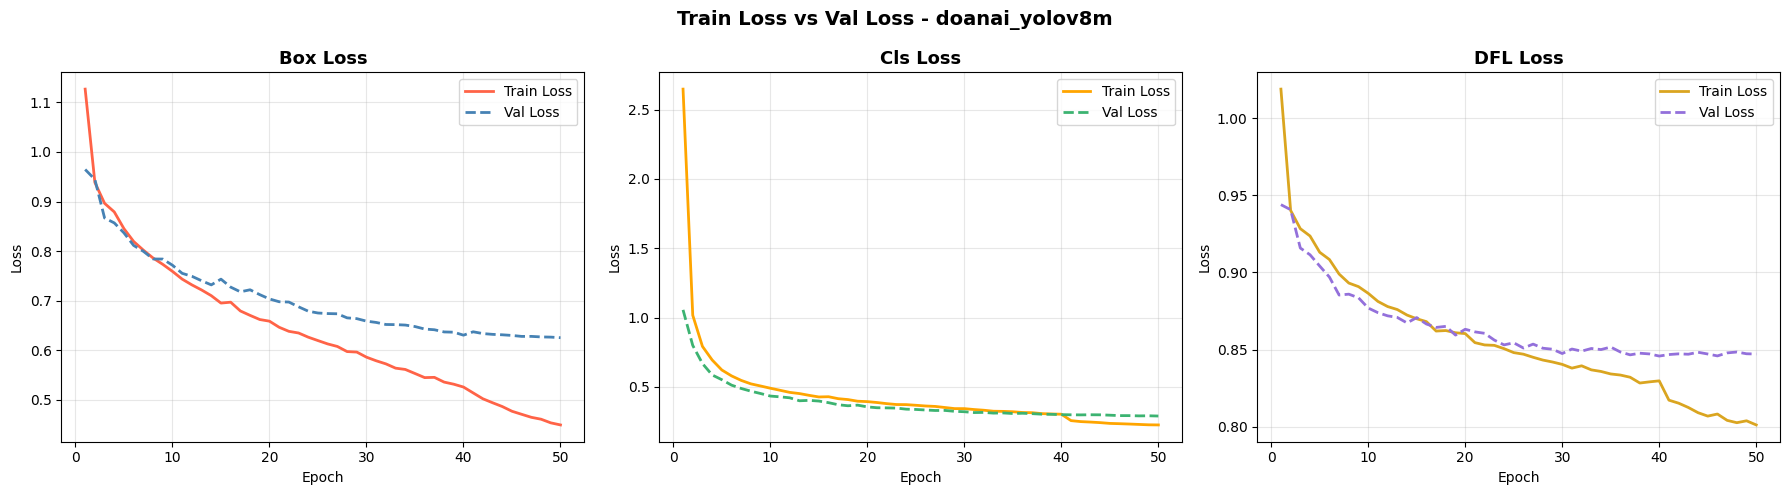

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2318.3±1130.6 MB/s, size: 140.2 KB)
val: Scanning /kaggle/working/dataset/val/labels.cache... 1230 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1230/1230 515.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 77/77 3.1it/s 25.2s0.5ss
                   all       1230       3959      0.972      0.973      0.983      0.816
Speed: 0.6ms preprocess, 16.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-7
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1917.9±542.5 MB/s, size: 260.1 KB)
val: Scanning /kaggle/working/dataset/test/labels.cache... 1230 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1230/1230 429.9Mit/s 0.0s
                 Class  

In [33]:
import cv2, matplotlib.pyplot as plt, pandas as pd
from pathlib import Path
from ultralytics import YOLO

# ── CONFIG: chỉ cần đổi tên model ở đây ──
MODEL_NAME = 'doanai_yolov8m'  # đổi thành tên folder trong /kaggle/working/

# ── Load model ──
model_best = YOLO(f'/kaggle/working/{MODEL_NAME}/weights/best.pt')

# ── 1. Predict ảnh test ──
test_imgs = list((WORK_DIR / 'test' / 'images').glob('*'))[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_path in enumerate(test_imgs):
    result = model_best.predict(str(img_path), conf=0.25, verbose=False)[0]
    img_plot = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_plot)
    axes[i].set_title(f'{len(result.boxes)} bien bao', fontsize=10)
    axes[i].axis('off')

plt.suptitle(f'Ket qua nhan dien - {MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/predictions.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 2. Train vs Val Loss ──
df = pd.read_csv(f'/kaggle/working/{MODEL_NAME}/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
loss_pairs = [
    ('train/box_loss', 'val/box_loss', 'Box Loss', axes[0], 'tomato',    'steelblue'),
    ('train/cls_loss', 'val/cls_loss', 'Cls Loss', axes[1], 'orange',    'mediumseagreen'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss', axes[2], 'goldenrod', 'mediumpurple'),
]

for train_col, val_col, title, ax, c_train, c_val in loss_pairs:
    if train_col in df.columns and val_col in df.columns:
        ax.plot(df['epoch'], df[train_col], color=c_train, linewidth=2, label='Train Loss')
        ax.plot(df['epoch'], df[val_col],   color=c_val,   linewidth=2, label='Val Loss', linestyle='--')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle(f'Train Loss vs Val Loss - {MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/train_val_loss.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 3. Evaluate thực tế ──
val_metrics  = model_best.val(data=str(yaml_path), split='val',  verbose=False)
test_metrics = model_best.val(data=str(yaml_path), split='test', verbose=False)

print('='*50)
print('         TONG KET DU AN')
print('='*50)
print(f'  Model         : {MODEL_NAME}')
print(f'  Dataset       : {len(train_list)+len(valid_list)+len(test_list)} anh / {len(classes)} class')
print(f'  Train/Val/Test: 80% / 10% / 10%')
print(f'  Epochs        : 50')
print(f'  -- VAL --')
print(f'  mAP@50        : {val_metrics.box.map50*100:.1f}%')
print(f'  mAP@50-95     : {val_metrics.box.map*100:.1f}%')
print(f'  -- TEST --')
print(f'  mAP@50        : {test_metrics.box.map50*100:.1f}%')
print(f'  mAP@50-95     : {test_metrics.box.map*100:.1f}%')
print(f'  Precision     : {test_metrics.box.mp*100:.1f}%')
print(f'  Recall        : {test_metrics.box.mr*100:.1f}%')
print('='*50)
print(f'  Model: /kaggle/working/{MODEL_NAME}/weights/best.pt')

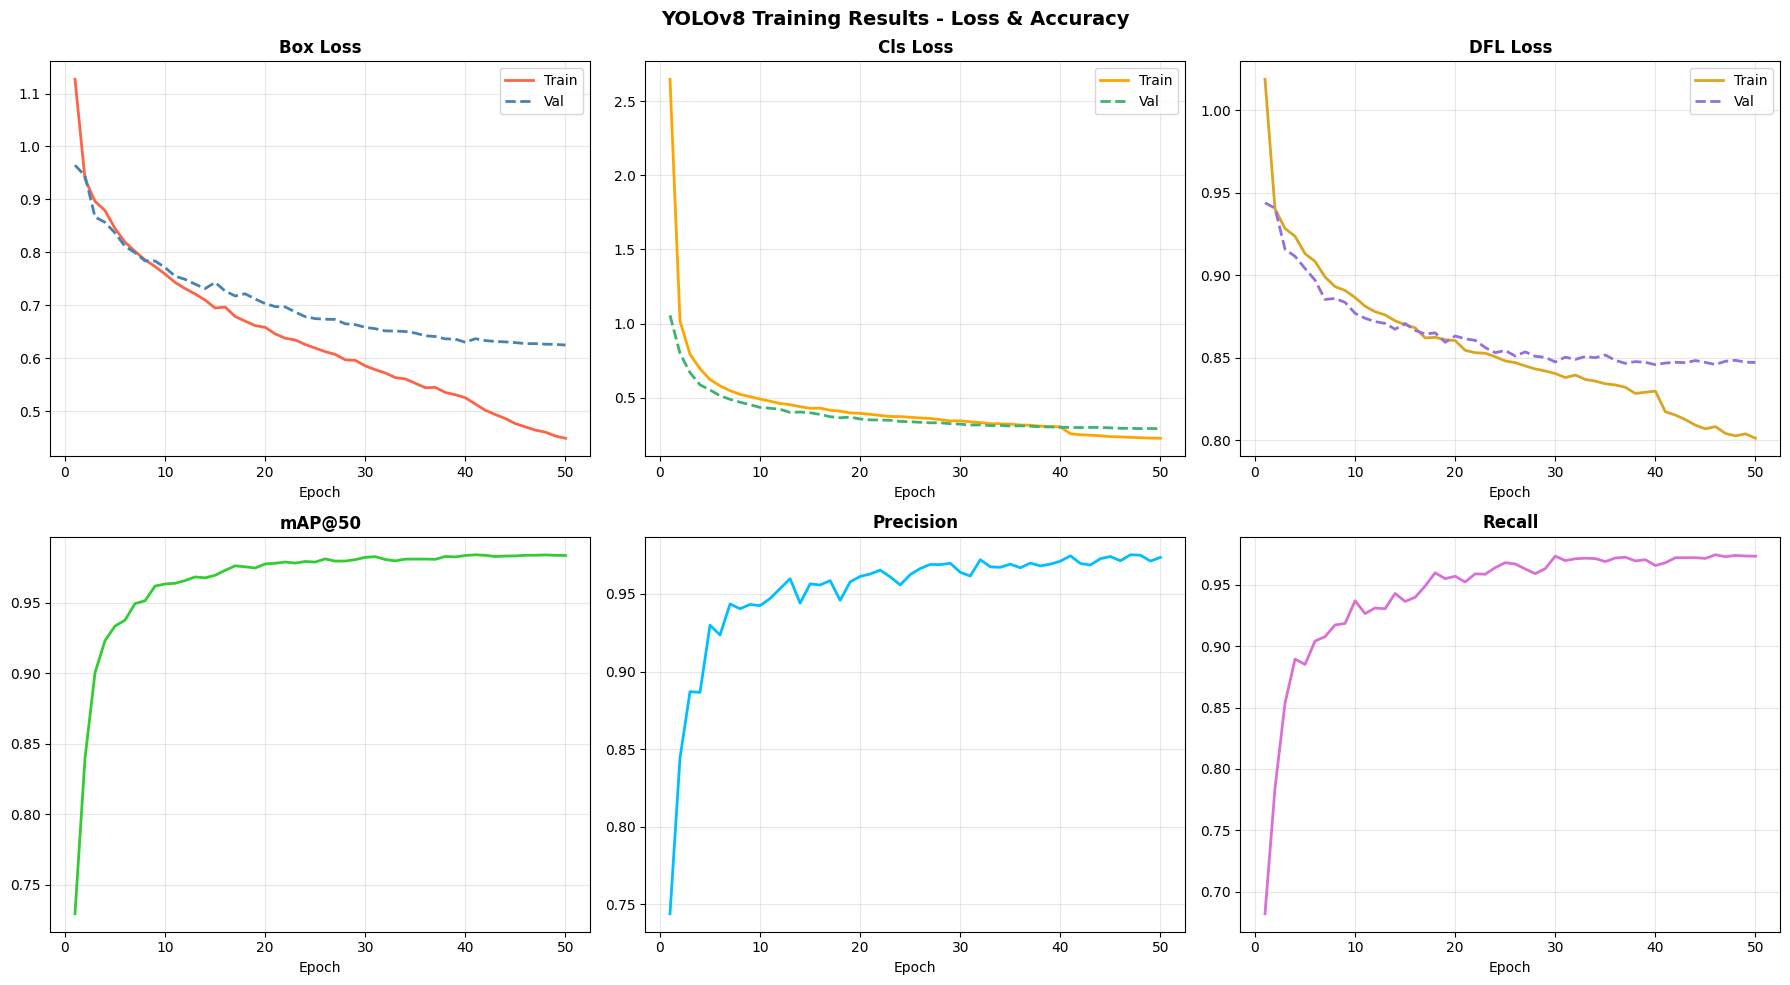

Done!


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/working/doanai_yolov8m/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plots = [
    # Row 1: Loss
    ('train/box_loss', 'val/box_loss', 'Box Loss',  axes[0,0], 'tomato',    'steelblue'),
    ('train/cls_loss', 'val/cls_loss', 'Cls Loss',  axes[0,1], 'orange',    'mediumseagreen'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss',  axes[0,2], 'goldenrod', 'mediumpurple'),
    # Row 2: Accuracy
    ('metrics/mAP50(B)',     'metrics/mAP50(B)',     'mAP@50',    axes[1,0], 'limegreen',   'limegreen'),
    ('metrics/precision(B)', 'metrics/precision(B)', 'Precision', axes[1,1], 'deepskyblue', 'deepskyblue'),
    ('metrics/recall(B)',    'metrics/recall(B)',    'Recall',    axes[1,2], 'orchid',      'orchid'),
]

for train_col, val_col, title, ax, c_train, c_val in plots:
    if train_col in df.columns:
        if train_col == val_col:
            # Metrics: chỉ 1 đường
            ax.plot(df['epoch'], df[train_col], color=c_train, linewidth=2)
        else:
            # Loss: 2 đường train vs val
            ax.plot(df['epoch'], df[train_col], color=c_train, linewidth=2, label='Train')
            ax.plot(df['epoch'], df[val_col],   color=c_val,   linewidth=2, label='Val', linestyle='--')
            ax.legend()
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.suptitle('YOLOv8 Training Results - Loss & Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/full_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Done!')

In [35]:
from pathlib import Path
from collections import defaultdict

# Đọc tất cả label trong train/val/test
class_count = {split: defaultdict(int) for split in ['train', 'val', 'test']}

for split in ['train', 'val', 'test']:
    lbl_dir = WORK_DIR / split / 'labels'
    for lbl_file in lbl_dir.rglob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                cls_id = int(line.strip().split()[0])
                class_count[split][cls_id] += 1

print(f'{"Class":<45} {"Train":>6} {"Val":>6} {"Test":>6}')
print('-' * 65)
for i, name in enumerate(classes):
    tr = class_count['train'].get(i, 0)
    va = class_count['val'].get(i, 0)
    te = class_count['test'].get(i, 0)
    flag = ' ⚠️' if va == 0 or te == 0 else ''
    print(f'{name:<45} {tr:>6} {va:>6} {te:>6}{flag}')

Class                                          Train    Val   Test
-----------------------------------------------------------------
Pedestrian Crossing                              569     83     83
Equal-level Intersection                         109     21     21
No Entry                                         706    118    134
Right Turn Only                                  699    116    128
Intersection                                     177     24     29
Intersection with a non-priority road            323     40     36
Danger zone on the left                          152     23     29
No Left Turn                                     372     53     63
Bus Stop                                         346     78     70
Roundabout                                       239     36     26
No Stopping and No Parking                      2577    373    373
U-Turn Allowed                                   145     17     20
Lane Allocation                                  271     50    